August 10th
## Asignement 3: Investigation of Richardson Extrapolation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

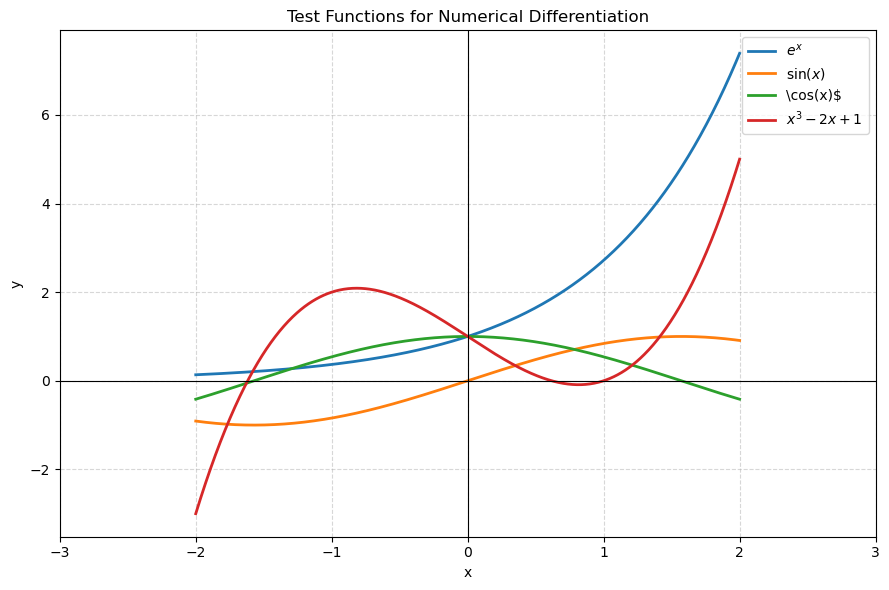

In [6]:
x = np.linspace(-2,2,1000)

#function definition
f1 = np.exp(x)
f2 = np.sin(x)
f3 = np.cos(x)
f4 = x**3 - 2*x + 1

plt.figure(figsize=(9,6))

plt.plot(x,f1,linewidth=2,label=r"$e^x$")
plt.plot(x,f2,linewidth=2,label=r"$\sin(x)$")
plt.plot(x,f3,linewidth=2,label=r"\cos(x)$")
plt.plot(x,f4,linewidth=2,label=r"$x^3-2x+1$")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Test Functions for Numerical Differentiation")

plt.axhline(0,color='black', linewidth=0.8)
plt.axvline(0,color='black', linewidth=0.8)

plt.grid(True,linestyle='--', alpha=0.5)
plt.legend()

plt.xlim(-3,3)

plt.tight_layout()
plt.show()


In [7]:
# Test functions

functions = {
    "e^x": np.exp,
    "sin(x)": np.sin,
    "cos(x)": np.cos,
    "x^3 - 2x + 1": lambda x: x**3 - 2*x + 1
}

# Exact derivatives

derivatives = {
    "e^x": np.exp,
    "sin(x)": np.cos,
    "cos(x)": lambda x: -np.sin(x),
    "x^3 - 2x + 1": lambda x: 3*x**2 - 2
}

In [9]:
x0 = 1

h_values = [
    1e-1,
    1e-2,
    1e-3,
    1e-4,
    1e-5,
    1e-6,
    1e-7,
    1e-8,
    1e-9,
    1e-10
]

print("Evaluation point:", x0)
print("Step sizes:", h_values)

Evaluation point: 1
Step sizes: [0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 1e-07, 1e-08, 1e-09, 1e-10]


In [10]:
def forward_difference(f,x,h):
    derivative = (f(x+h) - f(x)) / h
    return derivative

In [11]:
result = forward_difference(functions["e^x"], x0, 0.1)

print("Forward Difference =", result)

Forward Difference = 2.858841954873883


In [12]:
def backward_difference(f,x,h):
    derivative = (f(x) - f(x - h)) / h
    return derivative

In [13]:
result = backward_difference(functions["e^x"], x0, 0.1)

print("Backward Difference =", result)

Backward Difference = 2.5867871730209524


In [14]:
def central_difference(f,x,h):
    derivative = (f(x+h) - f(x-h)) / (2*h)
    return derivative

In [15]:
result = central_difference(functions["e^x"], x0, 0.1)

print("Central Difference =", result)

Central Difference = 2.7228145639474177


In [17]:
def richardson_extrapolation(f,x,h):
    D_h = central_difference(f,x,h)
    D_h2 = central_difference(f,x,h/2)

    R = (4 * D_h2 - D_h) / 3
    return R


In [18]:
result = richardson_extrapolation(functions["e^x"], x0, 0.1)

print("Richardson Extrapolation =", result)

Richardson Extrapolation = 2.718281261981766


In [20]:
import pandas as pd

results = []

for name in functions:
    f = functions[name]
    df = derivatives[name]

    exact = df(x0)

    for h in h_values:

        forward = forward_difference(f, x0, h)
        backward = backward_difference(f, x0, h)
        central = central_difference(f, x0, h)
        richardson = richardson_extrapolation(f, x0, h)

        forward_error = abs(exact - forward)
        backward_error = abs(exact - backward)
        central_error = abs(exact - central)
        richardson_error = abs(exact - richardson)

        results.append([
            name,
            h,
            exact,
            forward,
            forward_error,
            backward,
            backward_error,
            central,
            central_error,
            richardson,
            richardson_error
        ])


columns = [
    "Function",
    "h",
    "Exact",
    "Forward_approx",
    "Forward_error",
    "Backward_approx",
    "Backward_error",
    "Central_approx",
    "Central_error",
    "Richardson_approx",
    "Richardson_error"
]


results_df = pd.DataFrame(results, columns=columns)


# Save to output.txt
with open("output.txt", "w") as file:
    file.write(
        results_df.to_string(
            index=False,
            float_format=lambda x: f"{x:.8e}"
        )
    )

print("Results saved successfully to output.txt")

Results saved successfully to output.txt


In [21]:
# Read and display the generated output file

with open("output.txt", "r") as file:
    output = file.read()

print(output)

    Function              h           Exact  Forward_approx  Forward_error  Backward_approx  Backward_error  Central_approx  Central_error  Richardson_approx  Richardson_error
         e^x 1.00000000e-01  2.71828183e+00  2.85884195e+00 1.40560126e-01   2.58678717e+00  1.31494655e-01  2.72281456e+00 4.53273549e-03     2.71828126e+00    5.66477279e-07
         e^x 1.00000000e-02  2.71828183e+00  2.73191866e+00 1.36368273e-02   2.70473561e+00  1.35462175e-02  2.71832713e+00 4.53049237e-05     2.71828183e+00    5.66910963e-11
         e^x 1.00000000e-03  2.71828183e+00  2.71964142e+00 1.35959407e-03   2.71692314e+00  1.35868798e-03  2.71828228e+00 4.53046679e-07     2.71828183e+00    4.02344824e-13
         e^x 1.00000000e-04  2.71828183e+00  2.71841775e+00 1.35918624e-04   2.71814592e+00  1.35909563e-04  2.71828183e+00 4.53056570e-09     2.71828183e+00    8.55759907e-13
         e^x 1.00000000e-05  2.71828183e+00  2.71829542e+00 1.35914977e-05   2.71826824e+00  1.35913805e-05  2.71828183e

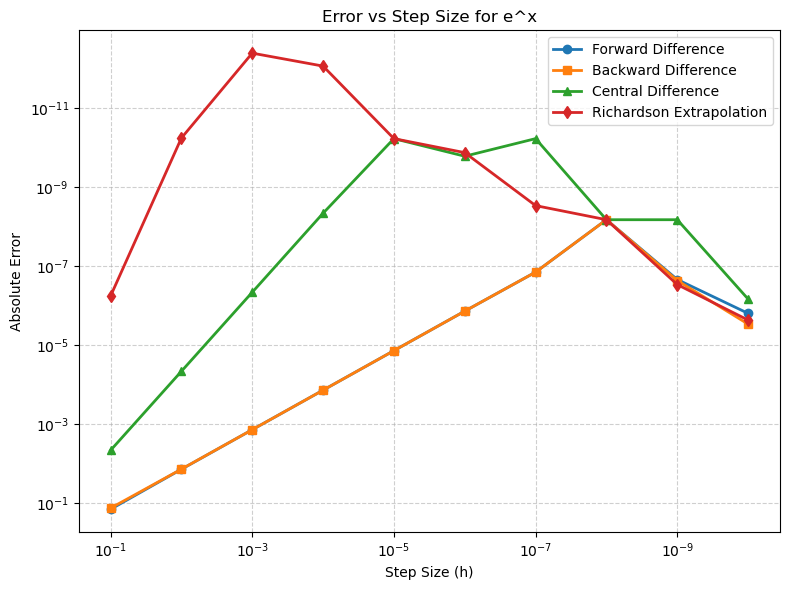

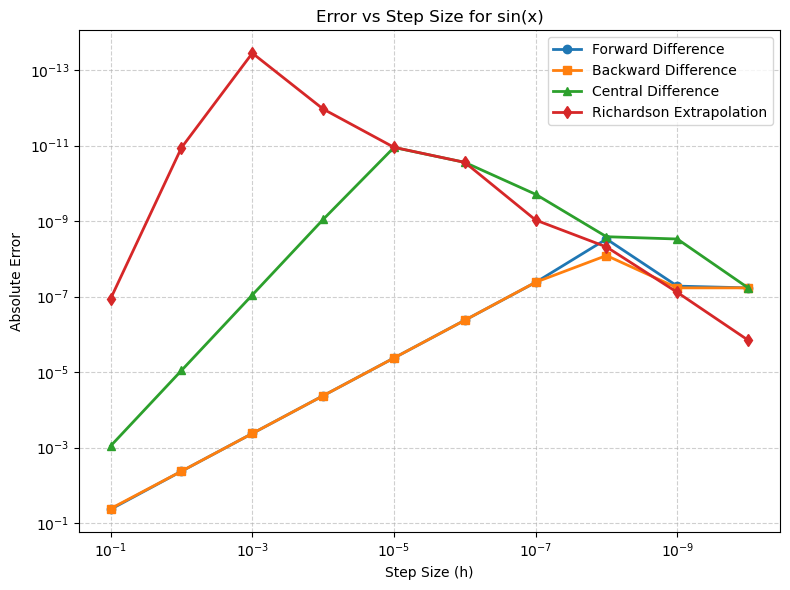

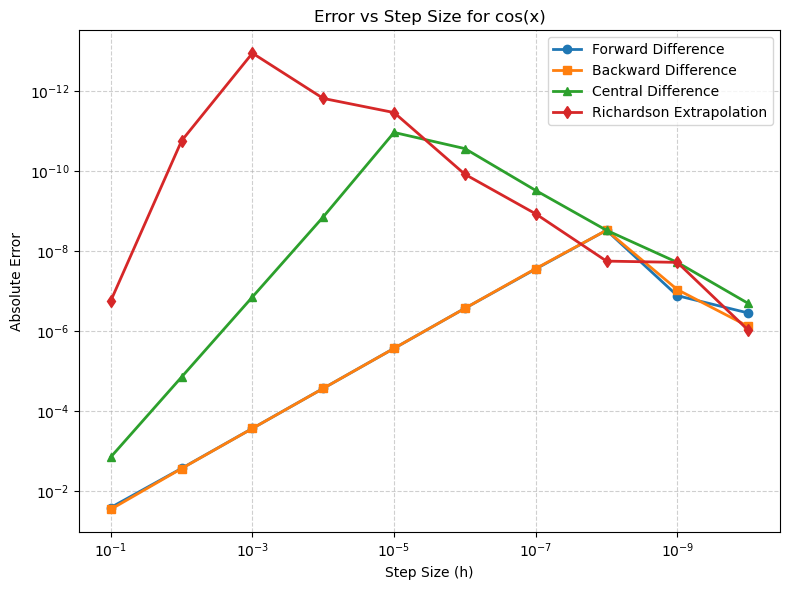

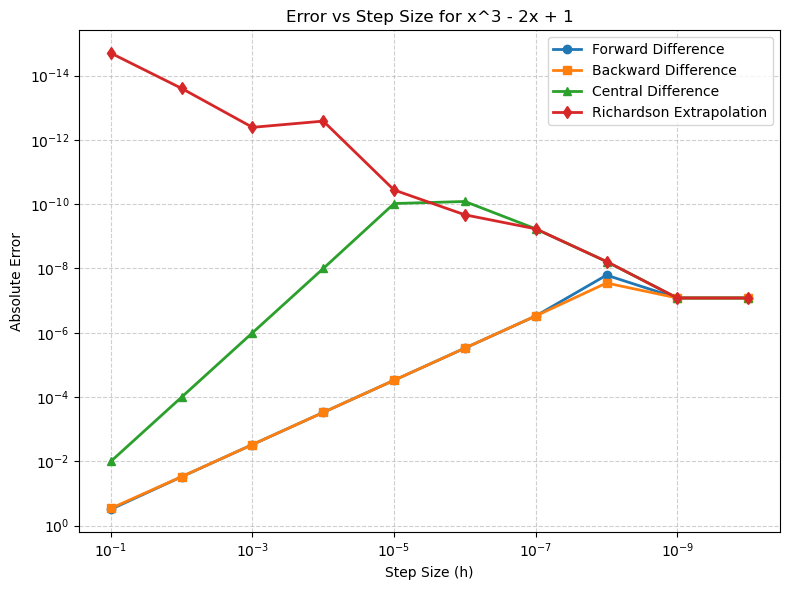

In [32]:
import matplotlib.pyplot as plt

function_names = list(functions.keys())

for name in function_names:

    data = results_df[results_df["Function"] == name]

    plt.figure(figsize=(8, 6))

    plt.loglog(
        data["h"],
        data["Forward_error"],
        'o-',
        linewidth=2,
        markersize=6,
        label="Forward Difference"
    )

    plt.loglog(
        data["h"],
        data["Backward_error"],
        's-',
        linewidth=2,
        markersize=6,
        label="Backward Difference"
    )

    plt.loglog(
        data["h"],
        data["Central_error"],
        '^-',
        linewidth=2,
        markersize=6,
        label="Central Difference"
    )

    plt.loglog(
        data["h"],
        data["Richardson_error"],
        'd-',
        linewidth=2,
        markersize=6,
        label="Richardson Extrapolation"
    )

    plt.xlabel("Step Size (h)")
    plt.ylabel("Absolute Error")
    plt.title(f"Error vs Step Size for {name}")
     # Flip x-axis:
    # 10^-1 on the left → 10^-10 on the right
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [24]:
import numpy as np

for name in functions:

    data = results_df[results_df["Function"] == name]

    log_h = np.log10(data["h"])

    forward_slope = np.polyfit(
        log_h,
        np.log10(data["Forward_error"]),
        1
    )[0]

    backward_slope = np.polyfit(
        log_h,
        np.log10(data["Backward_error"]),
        1
    )[0]

    central_slope = np.polyfit(
        log_h,
        np.log10(data["Central_error"]),
        1
    )[0]

    richardson_slope = np.polyfit(
        log_h,
        np.log10(data["Richardson_error"]),
        1
    )[0]

    print(f"\nFunction: {name}")
    print(f"Forward Difference      : {forward_slope:.4f}")
    print(f"Backward Difference     : {backward_slope:.4f}")
    print(f"Central Difference      : {central_slope:.4f}")
    print(f"Richardson Extrapolation: {richardson_slope:.4f}")


Function: e^x
Forward Difference      : 0.6955
Backward Difference     : 0.6779
Central Difference      : 0.4589
Richardson Extrapolation: -0.3844

Function: sin(x)
Forward Difference      : 0.7448
Backward Difference     : 0.7285
Central Difference      : 0.4326
Richardson Extrapolation: -0.4342

Function: cos(x)
Forward Difference      : 0.6585
Backward Difference     : 0.6497
Central Difference      : 0.3910
Richardson Extrapolation: -0.3880

Function: x^3 - 2x + 1
Forward Difference      : 0.8148
Backward Difference     : 0.8057
Central Difference      : 0.4980
Richardson Extrapolation: -0.8842


In [25]:
for name in functions:

    data = results_df[results_df["Function"] == name].sort_values("h", ascending=False)

    h = data["h"].values

    forward_error = data["Forward_error"].values
    backward_error = data["Backward_error"].values
    central_error = data["Central_error"].values
    richardson_error = data["Richardson_error"].values

    forward_order = np.log(forward_error[:-1] / forward_error[1:]) / \
                    np.log(h[:-1] / h[1:])

    backward_order = np.log(backward_error[:-1] / backward_error[1:]) / \
                     np.log(h[:-1] / h[1:])

    central_order = np.log(central_error[:-1] / central_error[1:]) / \
                    np.log(h[:-1] / h[1:])

    richardson_order = np.log(richardson_error[:-1] / richardson_error[1:]) / \
                       np.log(h[:-1] / h[1:])

    print("\nFunction:", name)
    print("\nh          Forward    Backward    Central    Richardson")
    
    for i in range(len(h) - 1):
        print(
            f"{h[i]:.0e} -> {h[i+1]:.0e}   "
            f"{forward_order[i]:8.4f}   "
            f"{backward_order[i]:8.4f}   "
            f"{central_order[i]:8.4f}   "
            f"{richardson_order[i]:10.4f}"
        )


Function: e^x

h          Forward    Backward    Central    Richardson
1e-01 -> 1e-02     1.0131     0.9871     2.0002       3.9997
1e-02 -> 1e-03     1.0013     0.9987     2.0000       2.1489
1e-03 -> 1e-04     1.0001     0.9999     2.0000      -0.3278
1e-04 -> 1e-05     1.0000     1.0000     1.8884      -1.8354
1e-05 -> 1e-06     1.0001     0.9999    -0.4456      -0.3548
1e-06 -> 1e-07     0.9872     0.9877     0.4456      -1.3401
1e-07 -> 1e-08     1.3262     1.3259    -2.0519      -0.3570
1e-08 -> 1e-09    -1.5136    -1.5394     0.0000      -1.6419
1e-09 -> 1e-10    -0.8564    -1.1022    -2.0081      -0.8978

Function: sin(x)

h          Forward    Backward    Central    Richardson
1e-01 -> 1e-02     1.0079     0.9912     1.9998       3.9991
1e-02 -> 1e-03     1.0008     0.9992     2.0000       2.5030
1e-03 -> 1e-04     1.0001     0.9999     2.0000      -1.4808
1e-04 -> 1e-05     1.0000     1.0000     1.9075      -1.0139
1e-05 -> 1e-06     1.0000     0.9999    -0.3958      -0.3988

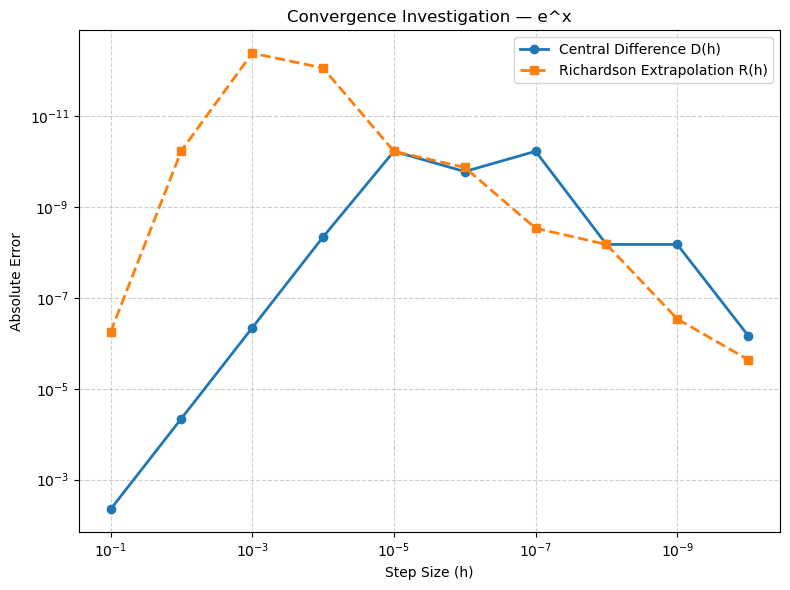

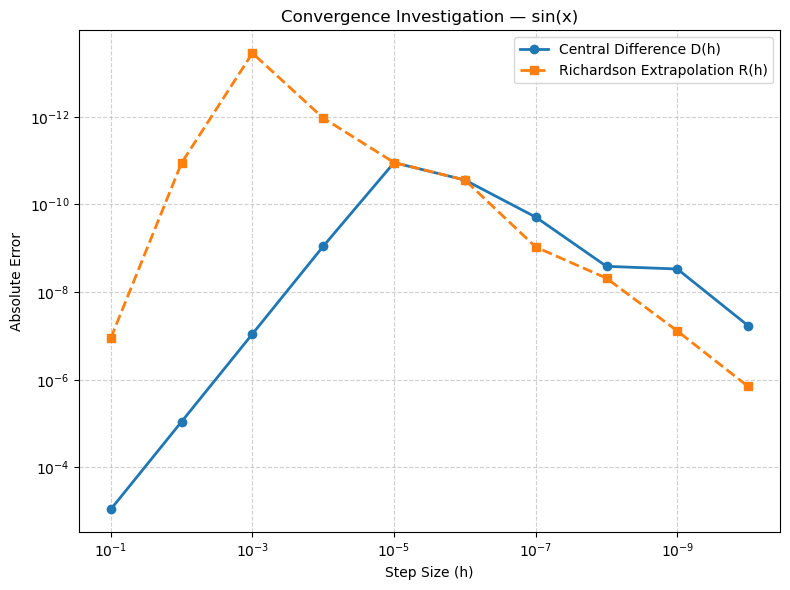

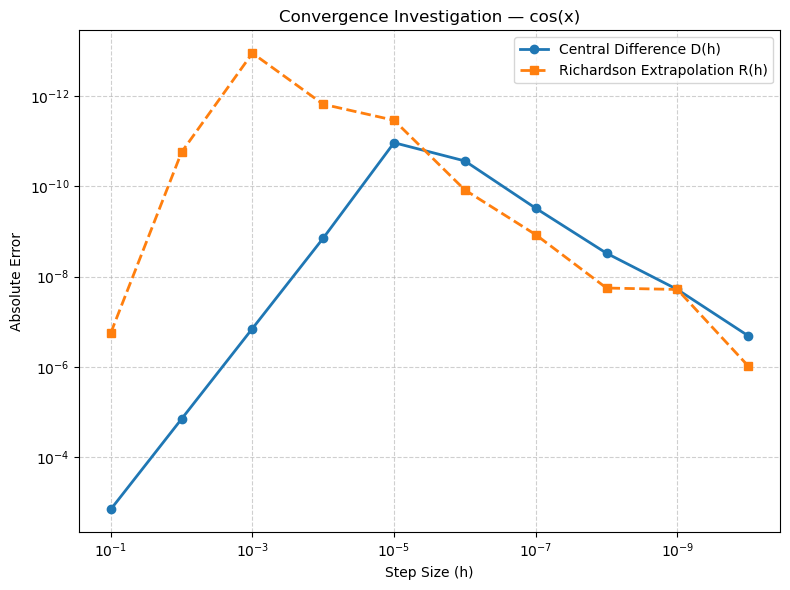

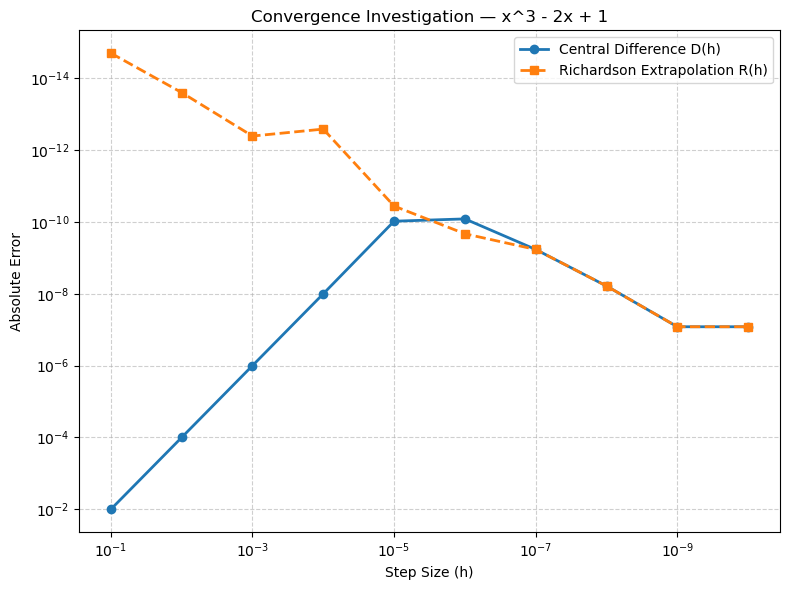

In [33]:
import matplotlib.pyplot as plt

assignment_III_functions = [
    "e^x",
    "sin(x)",
    "cos(x)",
    "x^3 - 2x + 1"
]

for name in assignment_III_functions:

    data = results_df[
        results_df["Function"] == name
    ].sort_values("h", ascending=False)

    plt.figure(figsize=(8, 6))

    plt.loglog(
        data["h"],
        data["Central_error"],
        'o-',
        linewidth=2,
        markersize=6,
        label="Central Difference D(h)"
    )

    plt.loglog(
        data["h"],
        data["Richardson_error"],
        's--',
        linewidth=2,
        markersize=6,
        label="Richardson Extrapolation R(h)"
    )

    plt.xlabel("Step Size (h)")
    plt.ylabel("Absolute Error")

    plt.title(
        f"Convergence Investigation — {name}"
    )

    # Flip x-axis:
    # 10^-1 on the left → 10^-10 on the right
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.grid(
        True,
        which="both",
        linestyle="--",
        alpha=0.6
    )

    plt.legend()

    plt.tight_layout()
    plt.show()